# Prediccion de conversion en e-commerce

## Que comportamiento web predice si un usuario terminara comprando?

**Autora:** Juliana Castano Yarce  
**Curso:** Modelado predictivo, automatizacion y proyectos inteligentes - Proyecto Final (Curso III)  
**Dataset:** Online Shoppers Purchasing Intention (UCI ML Repository)  
**Enfoque:** Prediccion supervisada - Clasificacion binaria

## Seccion 1 - Problema y datos

### Pregunta de investigacion

> **¿Podemos predecir si una sesion de e-commerce terminara en compra, y que comportamientos del usuario son los que mas influyen en esa prediccion?**

### ¿Por que es interesante?

Cada vez que una persona entra a una tienda online, genera un "rastro" de comportamiento:
cuantas paginas visita, cuanto tiempo pasa, en que momento del año entra, si llega desde una
campaña de marketing, etc. La mayoria de esas sesiones **no** terminan en compra.

Si una tienda pudiera **predecir con antelacion** cuales sesiones tienen alta probabilidad de
convertir, podria actuar sobre ellas (por ejemplo: mostrar un descuento, un recordatorio o
atencion personalizada). Y si ademas **se entiende** que comportamientos pesan mas en esa
decision, el negocio puede enfocar sus esfuerzos donde de verdad importa.

### Enfoque elegido: Prediccion supervisada (clasificacion binaria)

Se eligio un enfoque de **prediccion supervisada**. "Supervisada" significa que el modelo
aprende a partir de ejemplos que ya tienen la respuesta correcta (para cada sesion historica se
sabe si termino o no en compra). "Clasificacion binaria" significa que la respuesta es una de
**dos categorias**: compra (`True`) o no compra (`False`).

### Datos

| Caracteristica | Detalle |
|---|---|
| **Fuente** | UCI Machine Learning Repository (Online Shoppers Purchasing Intention Dataset) |
| **Tamaño** | 12.330 sesiones (filas) x 18 variables (columnas) |
| **Variable objetivo** | `Revenue` (`True` = la sesion termino en compra, `False` = no) |
| **Reto clave** | Solo ~15% de las sesiones terminan en compra → es un dataset **desbalanceado** |

La distribucion real de la variable objetivo se revisa mas adelante, en la exploracion (celda 1.6).


### Sobre el dataset: origen y variables

- **Fuente:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset), una biblioteca publica de datasets para investigacion.
- **Origen:** datos reales de analitica web (tipo Google Analytics) de una tienda online, recopilados durante ~1 año. Provienen del paper de Sakar et al. (2019).
- **La tienda esta anonimizada:** no se conoce su nombre ni que productos vende. Es un comercio electronico generico, y eso no afecta el analisis porque el foco esta en el **comportamiento de navegacion**, no en los productos.

**¿Que es una sesion?** Cada fila del dataset es una **visita** de un usuario a la web (desde que entra hasta que se va). Las 12.330 sesiones corresponden a usuarios distintos a lo largo del año.

**Tipos de pagina:** el sitio agrupa sus paginas en 3 familias. Por cada una se mide cuantas visito el usuario y cuanto tiempo paso en ellas:

| Familia | Que es | Columnas |
|---|---|---|
| Administrative | Paginas de gestion: cuenta, login, registro | `Administrative`, `Administrative_Duration` |
| Informational | Paginas de info: "sobre nosotros", contacto, FAQ | `Informational`, `Informational_Duration` |
| ProductRelated | Paginas de producto: catalogo, fichas | `ProductRelated`, `ProductRelated_Duration` |

**Resto de variables:** `BounceRates` y `ExitRates` (tasas de rebote y de salida), `PageValues` (valor promedio de las paginas visitadas, una metrica de Google Analytics), `SpecialDay` (cercania a una fecha especial como San Valentin), `Month` (mes), `OperatingSystems` / `Browser` / `Region` / `TrafficType` (codigos del sistema, navegador, region y tipo de trafico), `VisitorType` (visitante nuevo o recurrente), `Weekend` (fin de semana) y `Revenue` (la variable objetivo: si la sesion termino en compra).

### 1.1 Importar las librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Librerias importadas correctamente")


Librerias importadas correctamente


### 1.2 Descargar el dataset desde UCI

In [2]:
import os
import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"
ruta_zip = "../data/online_shoppers.zip"
ruta_csv = "../data/online_shoppers_intention.csv"

# Se descarga solo si el CSV no existe, para no volver a bajarlo en cada ejecucion
if not os.path.exists(ruta_csv):
    print("El CSV no existe todavia. Descargando desde UCI...")
    urllib.request.urlretrieve(url, ruta_zip)
    with zipfile.ZipFile(ruta_zip, "r") as z:
        z.extractall("../data")
    os.remove(ruta_zip)
    print("Descarga completa. CSV guardado en:", ruta_csv)
else:
    print("El CSV ya estaba descargado:", ruta_csv)


El CSV ya estaba descargado: ../data/online_shoppers_intention.csv


### 1.3 Cargar el dataset

In [3]:
df = pd.read_csv(ruta_csv)
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 1.4 Dimensiones y tipos de datos

In [4]:
print("Filas y columnas:", df.shape)
print()
df.info()


Filas y columnas: (12330, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int6

**Interpretacion:** El dataset tiene **12.330 sesiones** y **18 columnas**, y **no hay valores nulos** (todas las columnas tienen 12.330 valores no-nulos), asi que no habra que rellenar datos faltantes.

Los tipos de datos son una mezcla: numericos (`int64`, `float64`), categoricos de texto (`object`: `Month`, `VisitorType`) y booleanos (`bool`: `Weekend`, `Revenue`).

> ⚠️ `OperatingSystems`, `Browser`, `Region` y `TrafficType` aparecen como numeros, pero en realidad son **codigos categoricos** (la "Region 3" no es mayor que la "Region 1", solo es otra region). Esto se tendra en cuenta al preparar los datos en la Seccion 2.

### 1.5 Estadisticas de las variables numericas

In [5]:
df.describe().round(2)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


**Interpretacion:** Las variables numericas tienen **escalas muy distintas**: por ejemplo `BounceRates` y `ExitRates` van de 0 a 0.2, mientras `ProductRelated_Duration` llega hasta ~64.000. Esta diferencia justifica **escalar** las variables numericas en la Seccion 2 (algunos modelos, como la Regresion Logistica, lo necesitan para no darle mas peso a una variable solo por tener numeros mas grandes).

Ademas, varias columnas (`Informational`, `PageValues`, `SpecialDay`) tienen el percentil 75% en 0: **la mayoria de las sesiones tienen valor 0** en ellas. Es esperable en datos de navegacion, donde no todos visitan paginas informativas ni llegan a paginas "valiosas".

### 1.6 Distribucion de la variable objetivo (`Revenue`)

Aqui se revisa que tan balanceadas estan las dos clases (compra vs. no compra). Es el punto mas importante de la exploracion, porque el balance entre clases define que metricas tienen sentido en la Seccion 2.

Numero de sesiones por clase:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Porcentaje por clase:
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


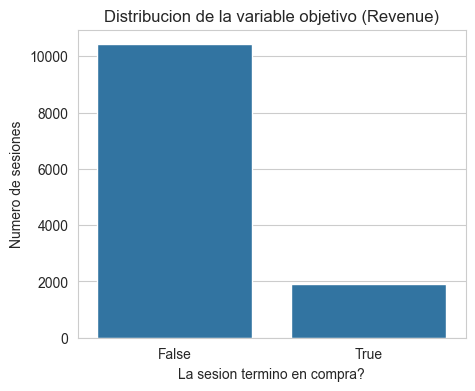

In [6]:
conteo = df["Revenue"].value_counts()
print("Numero de sesiones por clase:")
print(conteo)

porcentaje = df["Revenue"].value_counts(normalize=True) * 100
print("\nPorcentaje por clase:")
print(porcentaje.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Revenue")
plt.title("Distribucion de la variable objetivo (Revenue)")
plt.xlabel("La sesion termino en compra?")
plt.ylabel("Numero de sesiones")
plt.show()


**Interpretacion:** Las clases estan muy **desbalanceadas**: de las 12.330 sesiones, solo **1.908 (15.47%)** terminaron en compra, frente a **10.422 (84.53%)** que no. Es decir, aproximadamente **1 de cada 6 sesiones** convierte.

Esto confirma el reto anticipado: un modelo que simplemente prediga "no compra" para todas las sesiones acertaria el ~84.5% de las veces, pero seria inutil porque nunca detectaria una compra real. Por eso en la Seccion 2 **no se usara solo la exactitud (accuracy)** como metrica, sino tambien **precision, recall y F1**, que si miden que tan bien se detecta la clase minoritaria (las compras).

### 1.7 Limpieza minima: valores nulos y duplicados

Antes de modelar se revisan dos cosas basicas: si faltan datos (valores nulos) y si hay filas repetidas (duplicados).

In [7]:
print("Valores nulos por columna:")
print(df.isnull().sum())

duplicados = df.duplicated().sum()
print("\nNumero de filas duplicadas:", duplicados)


Valores nulos por columna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Numero de filas duplicadas: 125


**Interpretacion:** No hay valores nulos en ninguna columna, asi que no es necesario rellenar datos. Si se encontraron **125 filas completamente duplicadas** (~1% de los datos).

Se decide **eliminarlas**, por dos razones: (1) es la practica estandar al limpiar datos, y (2) evita la **fuga de datos** (*data leakage*) que ocurriria si una copia de una fila duplicada quedara en el conjunto de entrenamiento y otra en el de prueba en la Seccion 2, lo que inflaria artificialmente el rendimiento del modelo.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dimensiones despues de eliminar duplicados:", df.shape)
print("Duplicados restantes:", df.duplicated().sum())


Dimensiones despues de eliminar duplicados: (12205, 18)
Duplicados restantes: 0


### 1.8 Resumen de la Seccion 1

| Aspecto | Hallazgo |
|---|---|
| Tamaño final | 12.205 sesiones (tras eliminar 125 duplicados) y 18 variables |
| Valores nulos | Ninguno |
| Variable objetivo | `Revenue` (compra / no compra) |
| Balance de clases | **Desbalanceado**: ~15.5% compra, ~84.5% no compra |
| Tipos de variables | Mezcla de numericas, categoricas (`Month`, `VisitorType`) y booleanas |
| Escalas | Muy distintas entre variables numericas |
| Codigos categoricos | `OperatingSystems`, `Browser`, `Region`, `TrafficType` son numeros pero representan categorias |

**Que implica esto para la Seccion 2 (Modelado):**

- Como las clases estan **desbalanceadas**, los modelos se evaluaran con **precision, recall y F1**, no solo con accuracy.
- Como las **escalas** son muy distintas, las variables numericas se **escalaran**.
- Como hay variables **categoricas** (incluidas las que estan "disfrazadas de numero"), se **codificaran** para que los modelos las entiendan.
- Todos estos pasos de preparacion se organizaran en un **Pipeline** de Scikit-learn, que los aplica de forma ordenada y reproducible.

Con los datos ya entendidos y limpios, en la Seccion 2 se entrenaran y compararan dos modelos: **Regresion Logistica** y **Random Forest**.

## Seccion 2 - Modelado / Analisis

_Pendiente: train/test split, Pipeline de Scikit-learn, comparacion de al menos 2 modelos, metricas apropiadas para un problema desbalanceado._

## Seccion 3 - Interpretacion

_Pendiente: SHAP aplicado al mejor modelo, minimo 3 visualizaciones con titulo e interpretacion._

## Seccion 4 - Conclusiones

_Pendiente: respuesta a la pregunta, limitaciones del analisis, recomendacion concreta._

## Seccion 5 - Uso de IA

_Pendiente: documentacion de como se usaron herramientas de IA durante el proyecto - que se pidio, que entregaron, que se ajusto._